# Matplotlib

In [83]:
import matplotlib.pyplot as plt

### Basic charts

![](https://res.cloudinary.com/codecrucks/image/upload/c_scale,w_700,h_327,dpr_2/f_webp,q_auto/v1648958444/chart-types.png?_i=AA)

### Chart selection roadmap

![](http://blog.atkcg.ru/wp-content/uploads/2015/07/1-%D0%B9-%D1%81%D0%BB%D0%B0%D0%B9%D0%B41.jpg)

Из чего состоит график:

![image.png](https://blog.logrocket.com/wp-content/uploads/2021/11/anatomy-figure.png)

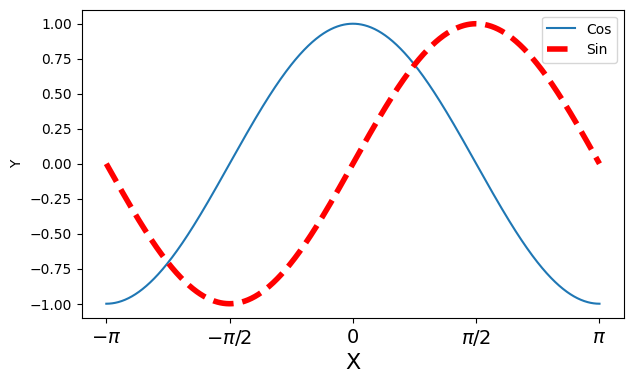

In [84]:
import numpy as np

plt.figure(figsize=(7, 4))
X = np.linspace(-np.pi, np.pi, 1000)
C, S = np.cos(X), np.sin(X)

plt.plot(X, C, label='Cos')
plt.plot(X, S, label='Sin', c='r', linestyle='--', linewidth=4)
plt.xlabel('X', fontsize=16)
plt.ylabel('Y')
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
           [r'$-\pi$', r'$-\pi/2$', 0, r'$\pi/2$', r'$\pi$'], fontsize=14)
plt.legend()
plt.show()

## Bonus

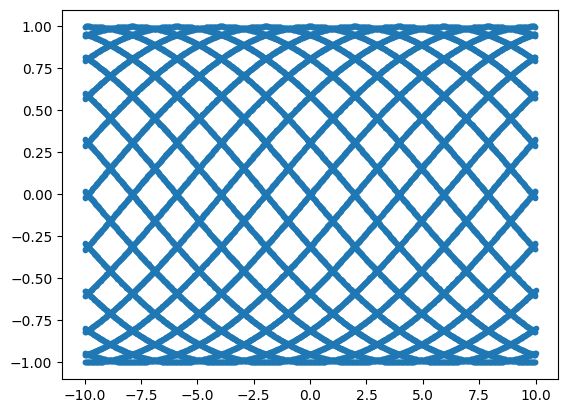

In [85]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-10, 10, 0.001) #set x=0.01, x=0.001 and see what happens
y = np.sin(314*x)

plt.plot(x,y, marker='.', linestyle='none')
plt.show()

# Homework

The data in [populations.txt](https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt) describes the populations of hares, lynxes and carrots in northern Canada during 20 years. Get the data with ```np.loadtxt('https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt')``` and do the following exercises **without for-loops**.


Plot the population size of each species for each year on a single graph. Add legend and axis labels to the plot.

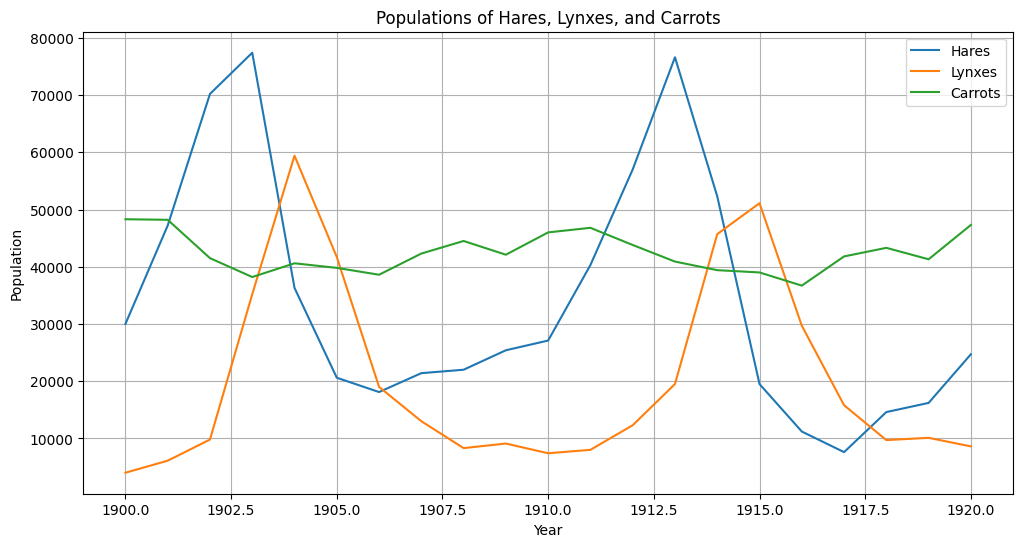

In [86]:
import numpy as np
import matplotlib.pyplot as plt

url = 'https://lectures.scientific-python.org/_downloads/087d8fe936fcb7a4762b9850b932cf9e/populations.txt'
data = np.loadtxt(url)

years = data[:, 0]
populations = data[:, 1:]

plt.figure(figsize=(12, 6))
plt.plot(years, populations[:, 0], label='Hares')
plt.plot(years, populations[:, 1], label='Lynxes')
plt.plot(years, populations[:, 2], label='Carrots')

plt.legend()
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Populations of Hares, Lynxes, and Carrots')
plt.grid(True)
plt.show()

Find which year each species had the largest population. Mark these years in the plot of populations.

Years with largest populations (Hares, Lynxes, Carrots): [1903. 1904. 1900.]


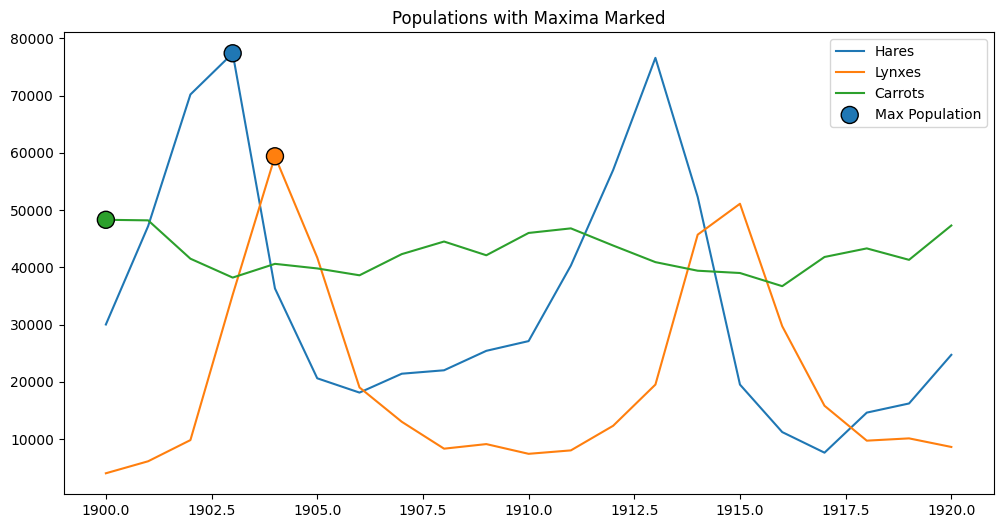

In [87]:
max_indices = np.argmax(populations, axis=0)
max_years = years[max_indices]
max_values = populations[max_indices, np.arange(populations.shape[1])]

print("Years with largest populations (Hares, Lynxes, Carrots):", max_years)

plt.figure(figsize=(12, 6))
plt.plot(years, populations[:, 0], label='Hares')
plt.plot(years, populations[:, 1], label='Lynxes')
plt.plot(years, populations[:, 2], label='Carrots')

plt.scatter(max_years, max_values, color=['tab:blue', 'tab:orange', 'tab:green'], s=150, zorder=5, edgecolors='black', label='Max Population')

plt.legend()
plt.title('Populations with Maxima Marked')
plt.show()

Assuming total population of hares and lynxes is 100%, plot stacked bar graph showing ratio of each specis for each year in the period.

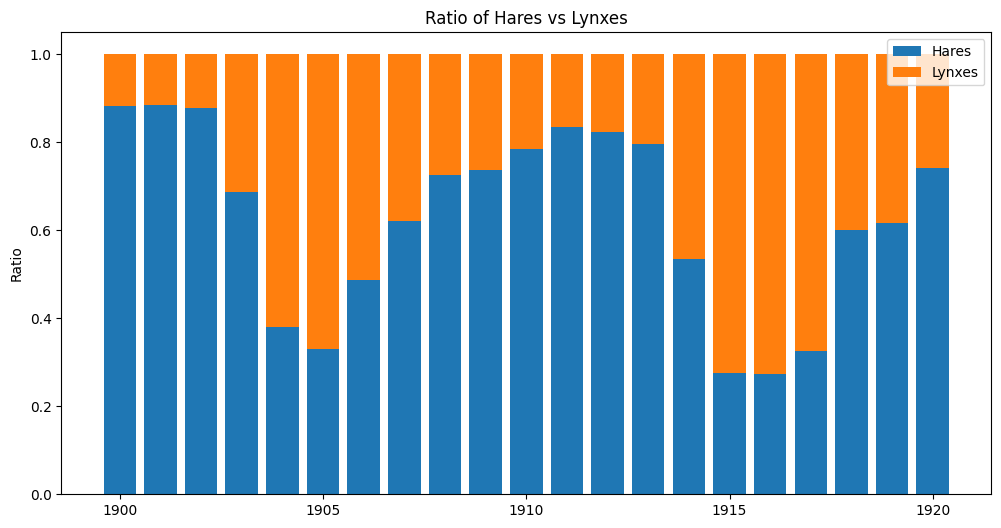

In [88]:
hares = populations[:, 0]
lynxes = populations[:, 1]
total = hares + lynxes

hares_ratio = hares / total
lynxes_ratio = lynxes / total

plt.figure(figsize=(12, 6))
plt.bar(years, hares_ratio, label='Hares')
plt.bar(years, lynxes_ratio, bottom=hares_ratio, label='Lynxes')

plt.legend()
plt.ylabel('Ratio')
plt.title('Ratio of Hares vs Lynxes')
plt.show()

Find the mean and std of the populations of each species. Plot the historgam of population for each species and show mean values with vertical line. Show each histogram in a separate plot. Arrange 3 plots in a row.

Mean values (Hares, Lynxes, Carrots): [34080.95238095 20166.66666667 42400.        ]
Std deviation (Hares, Lynxes, Carrots): [20897.90645809 16254.59153691  3322.50622558]


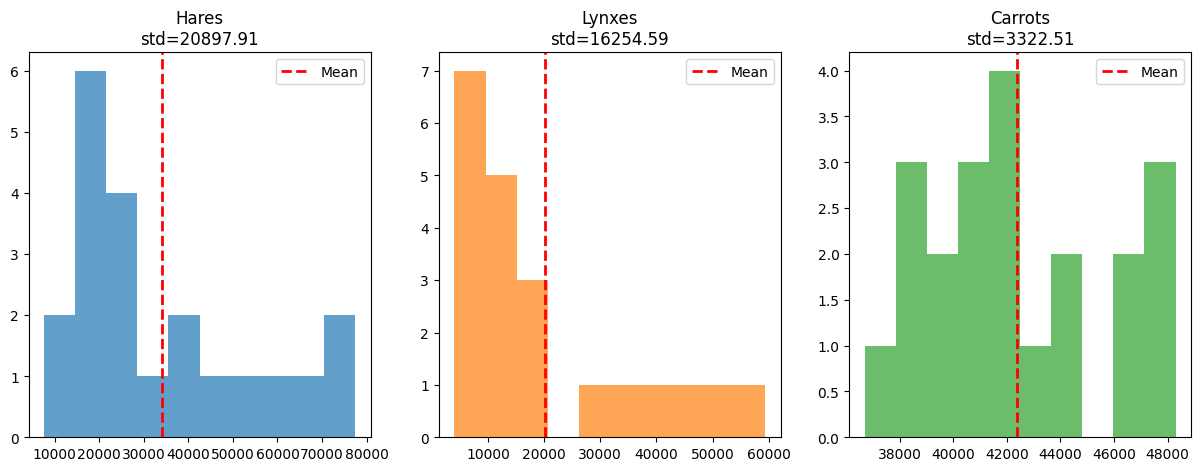

In [89]:
means = np.mean(populations, axis=0)
stds = np.std(populations, axis=0)

print(f"Mean values (Hares, Lynxes, Carrots): {means}")
print(f"Std deviation (Hares, Lynxes, Carrots): {stds}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(populations[:, 0], bins=10, color='tab:blue', alpha=0.7)
axes[0].axvline(means[0], color='red', linestyle='dashed', linewidth=2, label='Mean')
axes[0].set_title(f'Hares\nstd={stds[0]:.2f}')
axes[0].legend()

axes[1].hist(populations[:, 1], bins=10, color='tab:orange', alpha=0.7)
axes[1].axvline(means[1], color='red', linestyle='dashed', linewidth=2, label='Mean')
axes[1].set_title(f'Lynxes\nstd={stds[1]:.2f}')
axes[1].legend()

axes[2].hist(populations[:, 2], bins=10, color='tab:green', alpha=0.7)
axes[2].axvline(means[2], color='red', linestyle='dashed', linewidth=2, label='Mean')
axes[2].set_title(f'Carrots\nstd={stds[2]:.2f}')
axes[2].legend()

plt.show()

Find which species (hares or lynxes) has the largest population for each year. Print the result as [H, H, L, H, ...]. Plot a pie chart showing the ratio of "H" and "L" values.

Dominant species by year: ['H' 'H' 'H' 'H' 'L' 'L' 'L' 'H' 'H' 'H' 'H' 'H' 'H' 'H' 'H' 'L' 'L' 'L'
 'H' 'H' 'H']


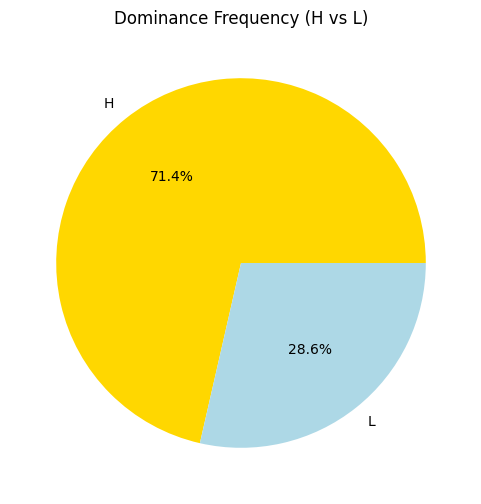

In [90]:
dominance = np.where(hares > lynxes, 'H', 'L')
print("Dominant species by year:", dominance)

unique, counts = np.unique(dominance, return_counts=True)

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=unique, autopct='%1.1f%%', colors=['gold', 'lightblue'])
plt.title('Dominance Frequency (H vs L)')
plt.show()

Plot the change in the hare population and in the lynx population for each year. Find the correlation coefficient between the both time series.

Correlation coefficient: -0.1780


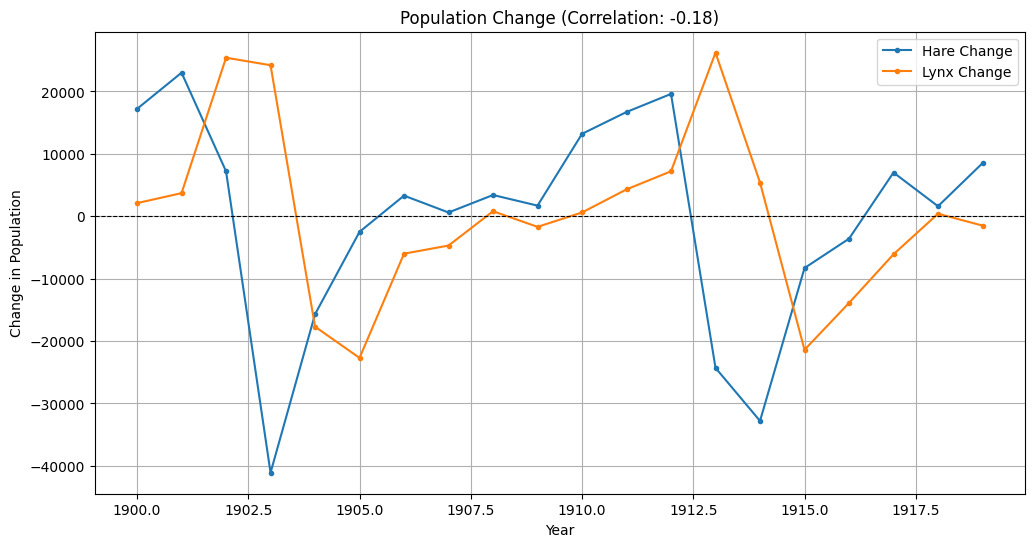

In [91]:
hare_change = np.diff(hares)
lynx_change = np.diff(lynxes)

correlation = np.corrcoef(hare_change, lynx_change)[0, 1]
print(f"Correlation coefficient: {correlation:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(years[:-1], hare_change, label='Hare Change', marker='.')
plt.plot(years[:-1], lynx_change, label='Lynx Change', marker='.')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Линия нуля

plt.legend()
plt.xlabel('Year')
plt.ylabel('Change in Population')
plt.title(f'Population Change (Correlation: {correlation:.2f})')
plt.grid(True)
plt.show()

Using a scatter plot, show the population of hares vs lynxes by year (each point corresponds to a particular year, and the point coordinates correspond to the population of the two species in that year).

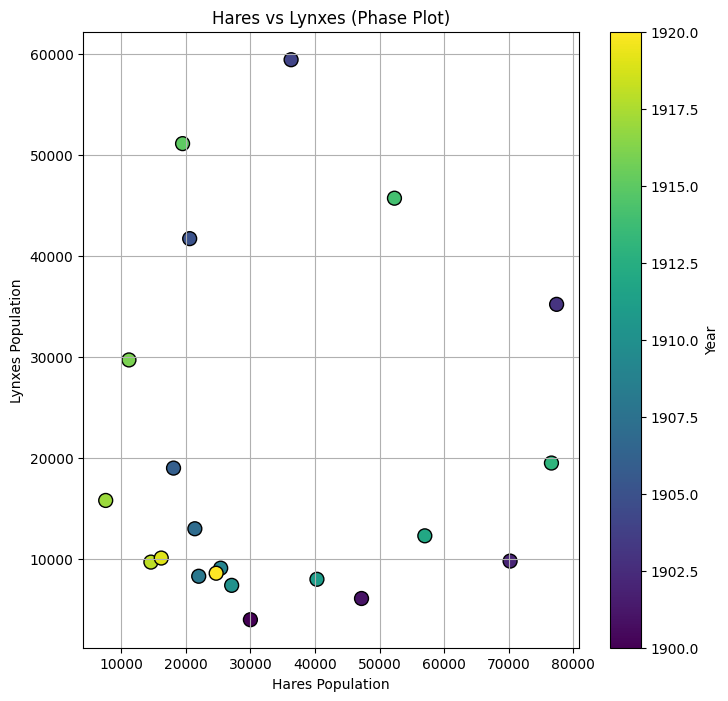

In [92]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(hares, lynxes, c=years, cmap='viridis', s=100, edgecolors='black')

plt.colorbar(scatter, label='Year')
plt.xlabel('Hares Population')
plt.ylabel('Lynxes Population')
plt.title('Hares vs Lynxes (Phase Plot)')
plt.grid(True)
plt.show()

Assume the population of hares in 1920 is unknown. Suggest a way to estimate this value. Compare an estimated value
with the true value and print a ratio of the error to the true value.

In [93]:
true_value_1920 = hares[-1]

hares_without_1920 = hares[:-1]
years_without_1920 = years[:-1]

estimated_value = np.median(hares_without_1920)

error = np.abs(estimated_value - true_value_1920)
error_ratio = error / true_value_1920

print(f"True value (1920): {true_value_1920}")
print(f"Estimated value (Median): {estimated_value}")
print(f"Error ratio: {error_ratio:.4f} ({error_ratio*100:.2f}%)")

True value (1920): 24700.0
Estimated value (Median): 26250.0
Error ratio: 0.0628 (6.28%)


### Let's practice: k-means clustering

<img src="https://stanford.edu/~cpiech/cs221/img/kmeansViz.png" width="800"/>

Входные данные в алгоритм: выборка, число кластеров, критерий остановки

Описание алгоритма:
* задаем начальное положение центров кластеров
* пока не выполнен критерий остановки:
  * распределяем точки к ближайшему центру
  * пересчитываем положения центров кластеров как центры масс образовавшихся кластеров

В качестве критерия остановки можно использовать малось изменения суммарной внутрикластерной дисперсии (суммы квадратов расстояний от каждой точки до центра ее кластера) и количество итераций.

### Датасет MNIST

Датасет MNSIT содержит примеры рукописных цифр. Загрузим датасет и посмотрим на примеры

In [94]:
from sklearn.datasets import fetch_openml

#Загрузка может занять около минуты
images, labels = fetch_openml('mnist_784', return_X_y=True, as_frame=False)

```images``` - массив картинок размера 28х28, вытянутых в вектор размера 784. Всего в датасете 70К примеров картинок

In [95]:
images.shape

(70000, 784)

```labels``` - массив, в котором записано, какая цифра нарисована на каждой картинке картинке

In [96]:
labels.shape

(70000,)

Нарисуем пример одной из картинок:

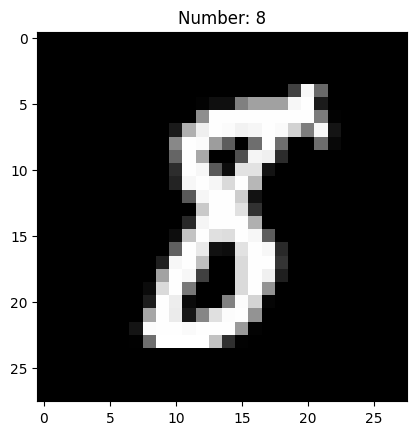

In [97]:
i = 125
plt.imshow(images[i].reshape(28, 28), cmap='Greys_r')
plt.title('Number: ' + labels[i])
plt.show()

Задание:

1) напишите функцию, реализующую алгоритм k-means.

Входом в функцию является

* массив NxM, где N -- число объектов, M -- число признаков объекта
* k -- число кластеров
* max_iter -- максимальное число итераций
* threshold -- критерий остановки (если на очередной итерации метода суммарное квадратичное отклонение изменяется меньше, чем на threshold, итерации прекращаются)

Выход:

* массив длины N, содержащий индексы кластеров от 0 до k-1
* суммарное квадратичное отклонение для полученного разбиения на кластеры

Постарайтесь обойтись минимальным количеством циклов в вашем коде.

2) Выделите 10 кластеров в датасете MNIST. Дайте интерпретацию каждому полученному кластеру (к какой цифре его можно отнести). Нарисуйте изображения, которые отвечают центрам кластеров. Посчитайте, сколько из точек кластера действительно являются той цифрой, к которой вы его отнесли (для этого сравните с массивом правильных ответов labels) и нарисуйте матрицу ошибок.

Problem 1

In [98]:
def k_means(X, k, max_iter=100, threshold=1e-4):
    """
    X: массив данных (N x M)
    k: число кластеров
    """
    n_samples = X.shape[0]

    rng = np.random.RandomState(42)
    indices = rng.permutation(n_samples)[:k]
    centroids = X[indices]

    labels = np.zeros(n_samples)

    for i in range(max_iter):
        X_sq = np.sum(X**2, axis=1).reshape(-1, 1)
        C_sq = np.sum(centroids**2, axis=1).reshape(1, -1)
        dists = X_sq + C_sq - 2 * X.dot(centroids.T)

        new_labels = np.argmin(dists, axis=1)

        new_centroids = np.zeros_like(centroids)
        for cluster_idx in range(k):
            cluster_points = X[new_labels == cluster_idx]
            if len(cluster_points) > 0:
                new_centroids[cluster_idx] = cluster_points.mean(axis=0)
            else:
                new_centroids[cluster_idx] = centroids[cluster_idx]

        shift = np.sum((centroids - new_centroids)**2)
        if shift < threshold:
            print(f"Converged at iteration {i}")
            break

        centroids = new_centroids
        labels = new_labels

    X_sq = np.sum(X**2, axis=1).reshape(-1, 1)
    C_sq = np.sum(centroids**2, axis=1).reshape(1, -1)
    dists = X_sq + C_sq - 2 * X.dot(centroids.T)
    min_dists = np.min(dists, axis=1)
    inertia = np.sum(min_dists)

    return labels, inertia, centroids

Problem 2

Loading MNIST data...
Running K-means...
Converged at iteration 74


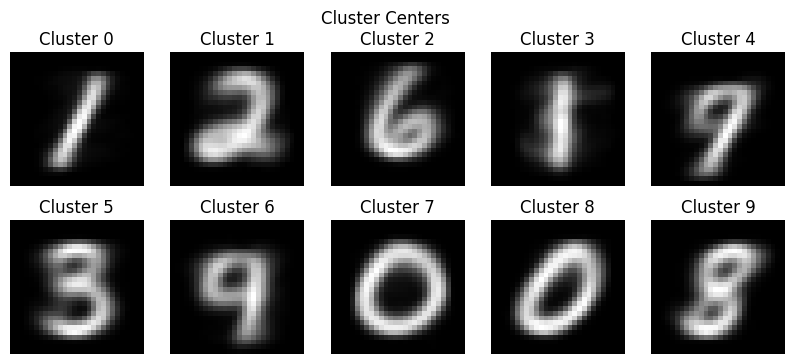

Cluster 0 maps to Digit 1
Cluster 1 maps to Digit 2
Cluster 2 maps to Digit 6
Cluster 3 maps to Digit 1
Cluster 4 maps to Digit 7
Cluster 5 maps to Digit 3
Cluster 6 maps to Digit 4
Cluster 7 maps to Digit 0
Cluster 8 maps to Digit 0
Cluster 9 maps to Digit 8


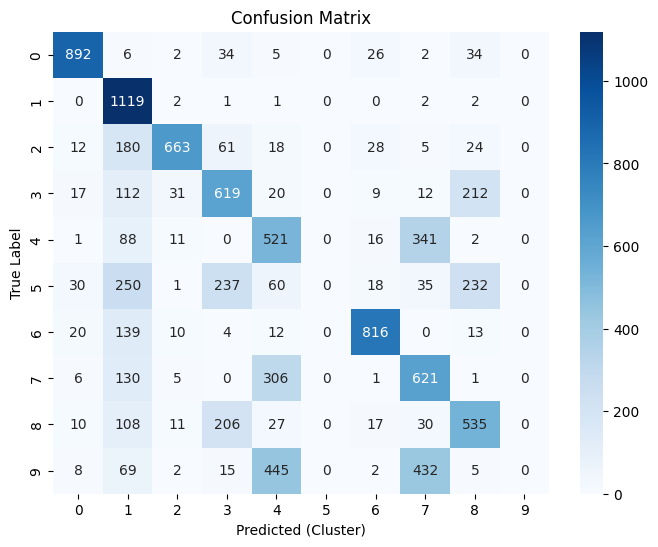

Accuracy: 57.86%


In [99]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("Loading MNIST data...")
X, y = fetch_openml('mnist_784', return_X_y=True, as_frame=False, parser='auto')

X = X / 255.0
y = y.astype(int)

X_small = X[:10000]
y_small = y[:10000]

print("Running K-means...")
labels, inertia, centers = k_means(X_small, k=10)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(centers[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f'Cluster {i}')
plt.suptitle('Cluster Centers')
plt.show()


mapped_labels = np.zeros_like(labels)
for i in range(10):
    mask = (labels == i)
    if np.any(mask):
        real_digit = np.bincount(y_small[mask]).argmax()
        mapped_labels[mask] = real_digit
        print(f"Cluster {i} maps to Digit {real_digit}")

cm = confusion_matrix(y_small, mapped_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted (Cluster)')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

acc = np.mean(mapped_labels == y_small)
print(f"Accuracy: {acc:.2%}")